
# <span style="color:rgb(213,80,0)">Blind Beamforming Algorithms</span>

When neither the direction of arrival nor a reference signal is available, the arrival direction and the beamformer must be determined adaptively. Two common methods are introduced below.

## Minimum\-Power Method

Assume that the interference is much stronger than the desired signal. Under a minimum\-power constraint, the interference is suppressed, leaving only the desired signal and noise at the output. Set the weight of the first array element to 1, use the other elements to predict the components in the first element that are correlated with them, and subtract those components from the first\-element output. Because the interference is much stronger than the desired signal, the strong interference is suppressed. This leads to the optimization problem $\left\lbrace \begin{array}{l} \min_w w^H R_{xx} w,\\ s.t.w^H c=1 \end{array}\right.$


The problem can again be solved using the method of Lagrange multipliers; the derivation is omitted here.


In [ ]:
lambda = 3e-2;
M = 6;
position = (0:M-1).' * lambda/2;
c = [1;zeros([M-1,1])];
steering_vector = @(theta) ...
    exp(-1j*2*pi/lambda * position * sind(theta));
SNR = -20;
INR = 20;
K = 5e3;%snapshots
s1 = wgn(1,K,SNR); % desired signal
interf1 = wgn(1,K,INR);
interf2 = wgn(1,K,INR);
noise = wgn(M,K,0);
% rn = (randn(1,K)+1j*randn(1,K))/sqrt(2);
% interf1 = (randn(1,K)+1j*randn(1,K))/sqrt(2);
% interf2 = (randn(1,K)+1j*randn(1,K))/sqrt(2);
% noise = (randn(M,K)+1j*randn(M,K))/sqrt(2);

theta = [10,-30,40];%three directions of arrival
S = [s1;interf1;interf2];
A = steering_vector(theta);
X = A*S+noise;
Rxx = X*X'/K;
w_norm = Rxx\c;
w_opt = w_norm/(c'*w_norm);

w_opt = 
   1.0000 + 0.0000i
   0.0653 - 0.0041i
   0.3296 - 0.1579i
  -0.1675 + 0.1544i
  -0.1898 + 0.2381i
   0.1638 - 0.3192i

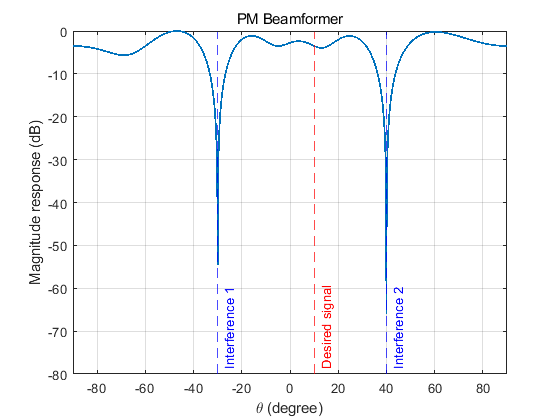

In [29]:
theta_plot = -90:0.1:90;
D_plot = steering_vector(theta_plot);     % M×Ntheta
P_LS_0 = w_opt'*D_plot;
BP_LS_0 = 20*log10( ...
    abs(P_LS_0)/max(abs(P_LS_0)) + eps);
figure;
h_bp = plot(theta_plot, BP_LS_0, 'LineWidth', 1.3);
grid on;
xlim([-90 90]);
ylim([-80 0]);
hold on;
h_desired = xline(theta(1), 'r--', 'Desired signal', ...
    'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
h_interf = gobjects(1, numel(theta)-1);
for ii = 2:numel(theta)
    h_interf(ii-1) = xline(theta(ii), 'b--', ...
        sprintf('Interference %d', ii-1), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('PM Beamformer');

In [30]:
% legend([h_bp h_desired h_interf(1)], ...
%     {'MVDR pattern', 'Desired direction', 'Interference direction'}, ...
%     'Location', 'best');

## CMA Algorithm

In wireless communications, the inherent properties of different modulation schemes can be used as beamformer constraints. This makes adaptive beamforming possible without knowing the signal's direction of arrival. Here we consider QPSK, a modulation scheme commonly used in communication systems.


First, consider the digital modulation schemes commonly used in communication systems, including PSK and FSK.


Digital modulation maps the bit stream to waveforms that can be transmitted through a channel. For memoryless modulation, the bit stream is first divided into groups, with every k bits mapped to one waveform $s_m (t)$ . Because binary bits take the values 0 or 1, every length\-k bit sequence has $2^k$ possibilities. This means that there are $M=2^k$ possible signal waveforms. A modulation scheme specifies how the bits are grouped and how each group is mapped to a baseband signal. Each


For PSK modulation, changes in carrier phase represent the symbols. Consider the simplest case, BPSK. Each bit maps to one of two waveforms: bit 0 maps to phase $0^{\circ }$ , and bit 1 maps to phase $180^{\circ }$ . The corresponding constellation points, or symbols, are 1 and \-1. QPSK groups bits in pairs, producing four bit groups $[00,01,10,11]$ . Communication systems generally use Gray mapping, so the corresponding symbol phases are $[\frac{\pi }{4},\frac{3\pi }{4},\frac{5\pi }{4},\frac{7\pi }{4}]$ . In a practical communication system, each symbol lasts for a finite interval and may therefore contain several samples. Here, one sample is used per symbol.



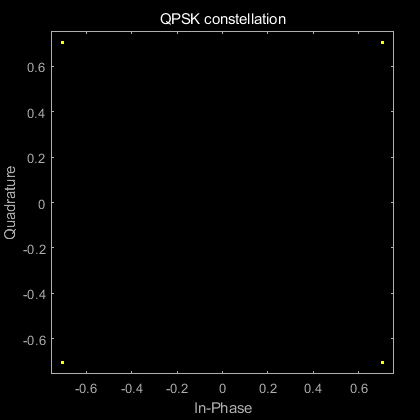

In [31]:
N = 5000;

% Generate the four symbol indices 0, 1, 2, and 3
data = randi([0, 3], N, 1);

% QPSK modulation with initial phase pi/4 and Gray mapping
s = pskmod(data, 4, pi/4, 'gray').';

gamma = mean(abs(s).^4) / mean(abs(s).^2);

scatterplot(s);
title('QPSK constellation');

In [32]:

fprintf('Average power = %.6f\n', mean(abs(s).^2));

Average power = 1.000000


In [33]:
fprintf('gamma = %.6f\n', gamma);

gamma = 1.000000


In [34]:

%% Array parameters
M = 12;

theta_s = 10;           % desired-signal direction
theta_i1 = -30;        % interference 1 direction
theta_i2 = 40;         % interference 2 direction

% Element indices of the half-wavelength-spaced uniform linear array
m = (0:M-1).';

% Steering vector; angle measured relative to the array broadside
steering = @(theta) exp(-1j * pi * m * sind(theta));

%% Unit-power complex Gaussian interference
i1 = (randn(1,N) + 1j*randn(1,N))/sqrt(2);
i2 = (randn(1,N) + 1j*randn(1,N))/sqrt(2);

%% Power settings
SNR_dB = 20;
INR1_dB = 20;
INR2_dB = 20;

Ps = 1;
Pn = Ps / 10^(SNR_dB/10);

Pi1 = Pn * 10^(INR1_dB/10);
Pi2 = Pn * 10^(INR2_dB/10);

%% Independent complex Gaussian noise at each element
V = sqrt(Pn/2) * ...
    (randn(M,N) + 1j*randn(M,N));

%% Array received-signal matrix
x = sqrt(Ps)  * steering(theta_s)  * s ...
  + sqrt(Pi1) * steering(theta_i1) * i1 ...
  + sqrt(Pi2) * steering(theta_i2) * i2 ...
  + V;



For a QPSK signal, the modulus is known to be constant at 1, whereas the moduli of interference and noise are not constant. During signal recovery, a constant\-modulus constraint can therefore be used to find the optimal weights and locate the constant\-modulus signal in space. The following cost function can be constructed:


 $J(w)=E\lbrace (y^2 (n)-\gamma )^2 )\rbrace$ , where $\gamma =\frac{E\lbrace |s_k |^4 \rbrace }{E\lbrace |s_k |^2 \rbrace }$ ， $s_k$ denotes a modulated symbol. Each QPSK symbol has unit modulus, so the cost function becomes


 $J(w)=E\lbrace (|y(n)|^2 -1)^2 \rbrace$ . Taking the Wirtinger derivative of the cost function gives


 $\frac{\partial J}{\partial w^* }=\frac{\partial }{\partial w^* }E\lbrace (|y(n)|^2 -1)^2 \rbrace =E\lbrace 2(|y(n)|^2 -1)\frac{\partial }{\partial w^* }(|y(n)|^2 -1)\rbrace =E\lbrace 2(|y(n)|^2 -1)\frac{\partial |y(n)|^2 }{\partial w^* }\rbrace$ ,


Since $y(n)=w^H x(n)$ , the partial derivative becomes


 $\frac{\partial J}{\partial w^* }=E\lbrace 2(|y(n)|^2 -1){x(n)}x^H (n)w\rbrace =E\lbrace 2(|y(n)|^2 -1)y^* (n){x(n)}\rbrace$ 。


This equation is difficult to solve directly. Instead, replace the expectation with its instantaneous value and use stochastic gradient descent to update the optimal weights.


$$w(n+1)=w(n)-\mu {\hat{\nabla} }_w J=w(n)-\mu (|y(n)|^2 -1)y^* (n){x(n)}$$

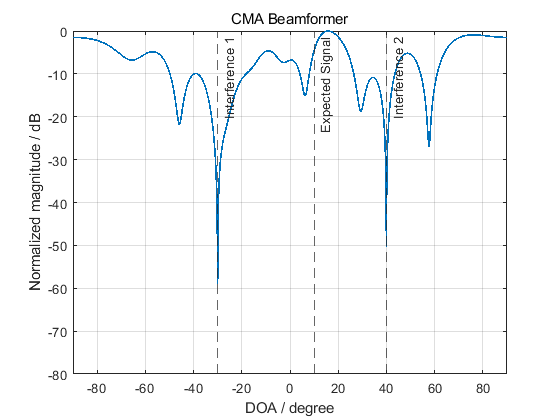

In [35]:

%CMA beamformer
rng(42)
w = randn(M,1) + 1j*randn(M,1);
% w = ones(M,1);
w = w / norm(w);
% w = zeros(M,1);
% w(1) = 1;
y = zeros(1, N);
mu = 1e-3;
for n = 1:N
    y(n) = w'*x(:,n);
    w = w - mu*(abs(y(n))^2-1)*conj(y(n))*x(:,n);
end
w_opt = w;
y = w_opt'*x;
%% Compute the final beam pattern
theta = -90:0.1:90;

A_scan = exp(-1j * pi * m * sind(theta));

P = w_opt' * A_scan;

BP = 20 * log10(abs(P) / max(abs(P)));

figure;
plot(theta, BP, 'LineWidth', 1.2);
grid on;

xlabel('DOA / degree');
ylabel('Normalized magnitude / dB');
title('CMA Beamformer');

xlim([-90, 90]);
ylim([-80, 0]);

xline(theta_s, '--', 'Expected Signal');
xline(theta_i1, '--', 'Interference 1');
xline(theta_i2, '--', 'Interference 2');

In [36]:

% Discard the initial convergence transient
steadyIndex = round(0.7 * N):N;
y = y(steadyIndex);

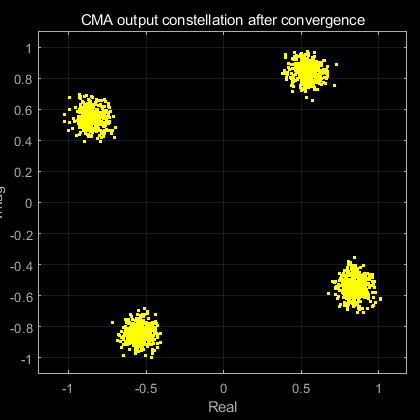

In [37]:
figure;
scatterplot(y)
grid on;
axis equal;

xlabel('Real');
ylabel('Imag');
title('CMA output constellation after convergence');

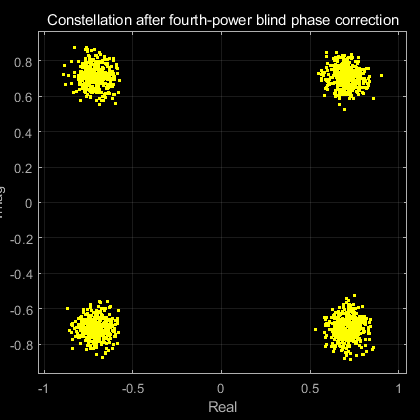

In [38]:

% Applicable to pskmod(...,4,pi/4,...)
phi_hat_blind = unwrap(angle(-mean(y.^4)) / 4);

y_blind_corrected = y * exp(-1j*phi_hat_blind);

figure;
scatterplot(y_blind_corrected)
grid on;
axis equal;
xlabel('Real');
ylabel('Imag');
title('Constellation after fourth-power blind phase correction');

## LS\-CMA Algorithm

The CMA algorithm is highly sensitive to the gradient parameter $\mu$ . In addition, standard CMA uses only one snapshot for each weight update. A more robust algorithm that does not depend on the gradient parameter is desirable. LS\-CMA is a constant\-modulus algorithm formulated in the least\-squares sense.


Rewrite the cost function as


 $J(w)=\sum_{n=1}^K ||y(n)|-1|^2 =\sum_{n=1}^K ||w^H x(n)|-1|^2$ . The goal is to find the weights that minimize the expression on the left, $w$ . Define the residual vector ${g(w)}=[|w^H x(1)|-1,|w^H x(2)|-1,...,|w^H x(K)|-1]^T$ . The original problem can then be rewritten as


 $J(w)=||{g(w)}||_2^2$ . Here, an extended Gauss\-Newton method is used to solve this nonlinear least\-squares problem.


Using Wirtinger calculus, the gradient is $\nabla J=\frac{\partial J}{\partial w^* }$ . A Taylor expansion of ${g(w)}$ gives


 $J({w+\Delta })=||{g(w+\Delta )}||_2^2 =||{g(w)}+D^H {\Delta }||_2^2$ , where $D=\left\lbrack \begin{array}{cccc} \nabla g_1 (w) & \nabla g_2 (w) & ... & \nabla g_K (w) \end{array}\right\rbrack$ 。


$$\begin{array}{l} J({w+\Delta })=[{g(w)}+D^H {\Delta }]^H [{g(w)}+D^H {\Delta }]\\ =||{g(w)}||_2^2 +{{\Delta }}^H D{g(w)}+g^H {(w)}D^H {\Delta }+{{\Delta }}^H DD^H {\Delta } \end{array}$$

. We seek an increment ${\Delta }$ such that $J({w+\Delta })$ is minimized. From the expanded result, it is easy to see that $J({w+\Delta })$ is a quadratic function of ${\Delta }$ . Taking its Wirtinger derivative with respect to ${\Delta }$ gives


 $\frac{\partial J({w+\Delta })}{\partial {{\Delta }}^* }=D{g(w)}+DD^H {\Delta }=0$ , and therefore ${\Delta }=-(DD^H )^{-1} D{g(w)}$ 。


. The iterative equation is thus


$$w(l+1)=w(l)-(D[w(l)]D^H [w(l)])^{-1} D[w(l)]g[w(l)]$$

 $\nabla g_k (w)=\frac{\partial (|w^H x(k)|-1)}{\partial w^* }$ . Since $\begin{array}{l} |f|^2 =f^* f\\ \left(|f|^2\right)^{\prime } =(f^* f)^{\prime } \\ 2|f||f|^{\prime } =f^* \frac{\partial f}{\partial {x^* }}+f\frac{\partial f^* }{\partial {x^* }}\\ |f|^{\prime } =\frac{1}{2|f|}(f^* \frac{\partial f}{\partial {x^* }}+f\frac{\partial f^* }{\partial {x^* }}) \end{array}$ , it follows that


 $\nabla g_k (w)=\frac{\partial (|w^H x(k)|-1)}{\partial w^* }=\frac{1}{2|w^H x(k)|}(x^H (k)wx(k))=\frac{1}{2}x(k)\frac{y^* (k)}{|y(k)|}$ . If the gradient is defined as $\nabla {g(w)}=2\frac{\partial g}{\partial w^* }$ , or if the factor 1/2 is simply omitted, then $\nabla g_k (w)=x(k)\frac{y^* (k)}{|y(k)|}$ . Omitting 1/2 does not materially affect the step size.


Therefore, $D[w(l)]=Xdiag(\frac{y^* (k)}{|y(k)|})=XY_{CM}$ , where $X=\left\lbrack \begin{array}{cccc} x(1) & x(2) & \ldots & x(k) \end{array}\right\rbrack$ . The iterative equation can be rewritten as


$$w(l+1)=w(l)-(XY_{CM} Y_{CM}^H X^H )^{-1} (XY_{CM} )g[w(l)]]=w(l)-(XX^H )^{-1} X\left\lbrack \begin{array}{c} y^* (1)-\frac{y^* (1)}{|y(1)|}\\ y^* (2)-\frac{y^* (2)}{|y(2)|}\\ \vdots \\ y^* (k)-\frac{y^* (k)}{|y(k)|} \end{array}\right\rbrack$$

. The column vector on the right\-hand side can be decomposed as $({y-r})^*$ , where $y=[y(1),y(2),\cdots ,y(k)]^T ,r=[\frac{y(1)}{|y(1)|},\frac{y(2)}{|y(2)|},\cdots ,\frac{y(k)}{|y(k)|}]^T$ 。


. The original equation becomes


$$\begin{array}{l} w(l+1)=w(l)-(XX^H )^{-1} X({y-r})^* \\ =w(l)-(XX^H )^{-1} Xy^* +(XX^H )^{-1} Xr^* \\ =w(l)-(XX^H )^{-1} XX^H w(l)+(XX^H )^{-1} Xr^* \\ =(XX^H )^{-1} Xr^*  \end{array}$$

. If we define ${\hat{R} }_{xx} =\frac{1}{K}XX^H ,{\hat{p} }_{xr} =\frac{1}{K}Xr^*$ , the iterative equation is equivalent to $w(l+1)={\hat{R} }_{xx}^{-1} {\hat{p} }_{xr}$ . This has the form of a Wiener solution, but unlike a Wiener solution there is no reference signal. Instead, a pseudo\-reference signal is generated by projecting the output signal onto the constant\-modulus set.


LS\-CMA has two operating modes. Static mode uses all data for every iteration. Dynamic mode updates the solution as new snapshots arrive, using a fixed number of snapshots in each iteration.


The static mode is shown below.


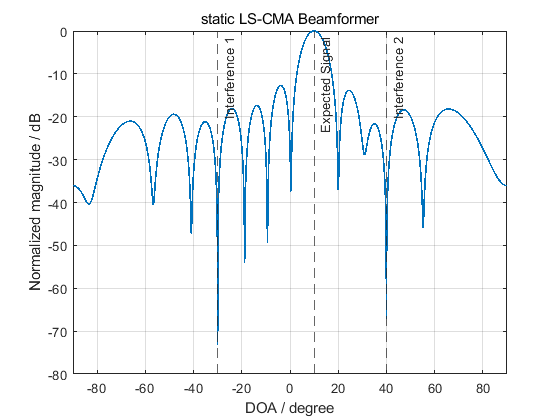

In [39]:
%static LS-CMA beamformer
rng(42)
w = randn(M,1) + 1j*randn(M,1);
w = w / norm(w);
% w = zeros(M,1);
% w(1) = 1;
y = zeros(1, N);
maxtier = 50;%maximum number of iterations
for l = 1:maxtier
   R = x*x';
   y = (w'*x).';
   r = y ./ abs(y);
   p = x*conj(r);
   w = R\p;
end
w_opt = w;
y = w_opt'*x;
%% Compute the final beam pattern
theta = -90:0.1:90;

A_scan = exp(-1j * pi * m * sind(theta));

P = w_opt' * A_scan;

BP = 20 * log10(abs(P) / max(abs(P)));

figure;
plot(theta, BP, 'LineWidth', 1.2);
grid on;

xlabel('DOA / degree');
ylabel('Normalized magnitude / dB');
title('static LS-CMA Beamformer');

xlim([-90, 90]);
ylim([-80, 0]);

xline(theta_s, '--', 'Expected Signal');
xline(theta_i1, '--', 'Interference 1');
xline(theta_i2, '--', 'Interference 2');

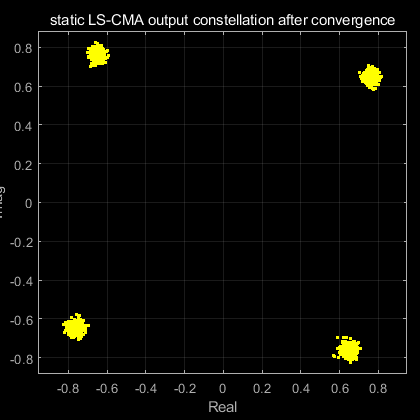

In [40]:

% Discard the initial convergence transient
steadyIndex = round(0.7 * N):N;
y = y(steadyIndex);
figure;
scatterplot(y)
grid on;
axis equal;

xlabel('Real');
ylabel('Imag');
title('static LS-CMA output constellation after convergence');

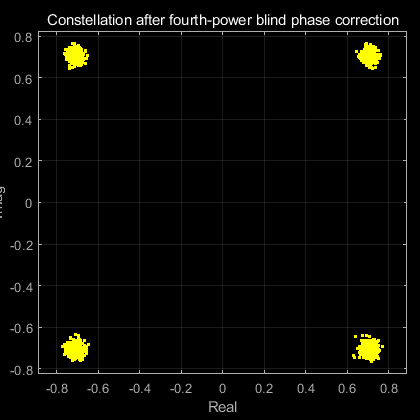

In [41]:

% Applicable to pskmod(...,4,pi/4,...)
phi_hat_blind = unwrap(angle(-mean(y.^4)) / 4);

y_blind_corrected = y * exp(-1j*phi_hat_blind);

figure;
scatterplot(y_blind_corrected)
grid on;
axis equal;
xlabel('Real');
ylabel('Imag');
title('Constellation after fourth-power blind phase correction');


In dynamic mode, the beamformer is updated in real time as snapshots arrive.


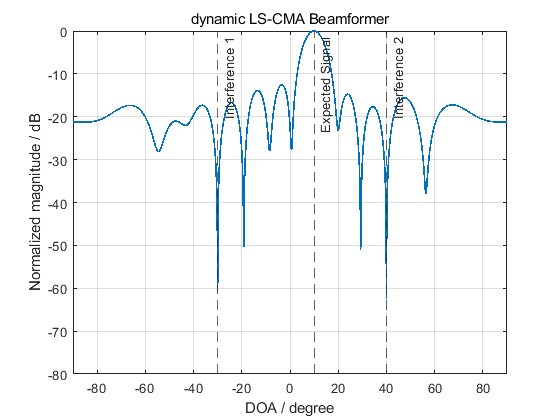

In [42]:
%dynamic LS-CMA beamformer
rng(42)
w = randn(M,1) + 1j*randn(M,1);
w = w / norm(w);
% w = zeros(M,1);
% w(1) = 1;
y = zeros(1, N);
datablocksize = 500;%snapshots used per update
for l = 1:K-datablocksize+1
   x_temp = x(:,l:l+datablocksize-1);
   R = x_temp*x_temp';
   y = (w'*x_temp).';
   r = y ./ abs(y);
   p = x_temp*conj(r);
   w = R\p;
end
w_opt = w;
y = w_opt'*x;
%% Compute the final beam pattern
theta = -90:0.1:90;

A_scan = exp(-1j * pi * m * sind(theta));

P = w_opt' * A_scan;

BP = 20 * log10(abs(P) / max(abs(P)));

figure;
plot(theta, BP, 'LineWidth', 1.2);
grid on;

xlabel('DOA / degree');
ylabel('Normalized magnitude / dB');
title('dynamic LS-CMA Beamformer');

xlim([-90, 90]);
ylim([-80, 0]);

xline(theta_s, '--', 'Expected Signal');
xline(theta_i1, '--', 'Interference 1');
xline(theta_i2, '--', 'Interference 2');

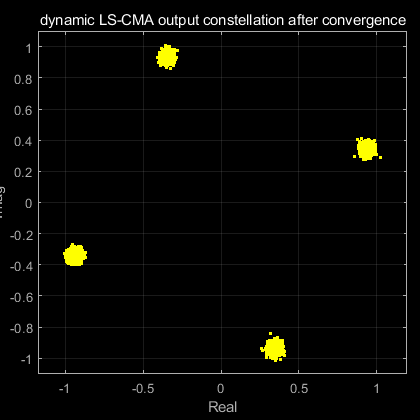

In [43]:

figure;
scatterplot(y)
grid on;
axis equal;

xlabel('Real');
ylabel('Imag');
title('dynamic LS-CMA output constellation after convergence');

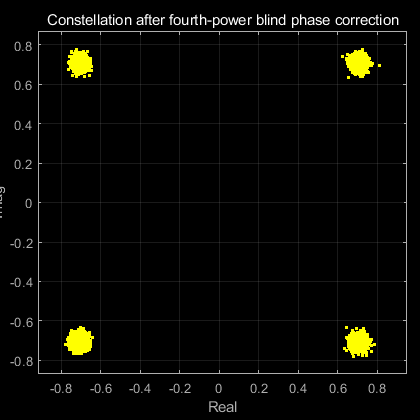

In [44]:

% Applicable to pskmod(...,4,pi/4,...)
phi_hat_blind = unwrap(angle(-mean(y.^4)) / 4);

y_blind_corrected = y * exp(-1j*phi_hat_blind);

figure;
scatterplot(y_blind_corrected)
grid on;
axis equal;
xlabel('Real');
ylabel('Imag');
title('Constellation after fourth-power blind phase correction');

## LS\-SCORE Algorithm

Besides constant modulus, other signal properties such as cyclostationarity can also be exploited.


Cyclostationarity means that a signal's second\-order statistics vary periodically with time. Its autocorrelation function changes with absolute time, so it is not wide\-sense stationary; instead, it is called cyclostationary.


Define the cyclic correlation function as


$$\begin{array}{l} R_{ss}^{\alpha } \triangleq \langle s(t+\frac{\tau }{2}),s^* (t-\frac{\tau }{2})e^{-j2\pi \alpha t} \rangle_{\infty } \\ R_{ss^* }^{\alpha } \triangleq \langle s(t+\frac{\tau }{2}),s(t-\frac{\tau }{2})e^{-j2\pi \alpha t} \rangle_{\infty }  \end{array}$$

and define the inner\-product notation as $\langle \cdot \rangle =\lim_{T\to \infty } \frac{1}{T}\int_{-\frac{T}{2}}^{\frac{T}{2}} (\cdot )dt$


Consider a QPSK signal as an example. Assume a symbol rate of 1 MHz and a pulse\-shaped QPSK signal.


The Gray\-mapped QPSK symbols are $a_k \in [\frac{1+j}{\sqrt{2}},\frac{-1+j}{\sqrt{2}},\frac{-1-j}{\sqrt{2}},\frac{1-j}{\sqrt{2}}]$ , and the pulse\-shaped baseband signal is


$$s(t)=\sum_{k=-\infty }^{+\infty } a_k p(t-kT_s )$$

. For independent, equiprobable QPSK symbols, $E[s(t)]=0$


$$R_{ss} (t,\tau )=E[s(t)s^* (t-\tau )]=E[\sum_{k=-\infty }^{+\infty } a_k p(t-kT_s )\cdot \sum_{k=-\infty }^{+\infty } a_l^* p^* (t-\tau -lT_s )]$$

Since $E[a_k a_l^* ]=\sigma_a^2 \delta [k-l]$


 $R_{ss} (t,\tau )=\sigma_a^2 E[\sum_{k=-\infty }^{+\infty } p(t-kT_s )\cdot p^* (t-\tau -kT_s )]$ , let $t=t+T_s$ ,


$$\begin{array}{l} R_{ss} (t+T_s ,\tau )=\sigma_a^2 E[\sum_{k=-\infty }^{+\infty } p(t+T_s -kT_s )\cdot p^* (t+T_s -\tau -kT_s )]\\ =\sigma_a^2 E[\sum_{k=-\infty }^{+\infty } p(t-(k-1)T_s )\cdot p^* (t-\tau -(k-1)T_s )]\\ =R_{ss} (t,\tau ) \end{array}$$

. Choosing $k^{\prime } =k-1$ gives the final equality. Thus, the autocorrelation function of the QPSK signal varies periodically at the symbol rate. Because the autocorrelation function is periodic in $t$ , it can be expanded as a Fourier series. Taking its Fourier transform gives the cyclic autocorrelation function: $\alpha$ is the cyclic frequency. For the QPSK baseband signal considered here, $\alpha =R_s =1{\mathrm{M}\mathrm{H}\mathrm{z}}$ . Thus, for a signal governed by a known protocol, such as QPSK with a specified baud rate, the cyclic autocorrelation should theoretically be nonzero at the baud rate. Communication signals commonly exhibit nonzero cyclic correlation at the symbol rate, chip rate, twice the carrier frequency, and related frequencies.


The LS\-SCORE algorithm uses spectral self\-coherence for blind beamforming. If the transmitted signal is known to be cyclostationary, a frequency\-shifted version of the input signal can be constructed as the reference. Assume the desired signal is $\alpha =\alpha_0$ . Its cyclic cross\-correlation with the frequency\-shifted signal then depends only on the desired signal. Construct the reference signal


 $r(n)=c^H x(n-D)e^{-j2\pi \alpha n}$ . To recover the signal's conjugate cyclostationarity, $x(n-D)$ should be conjugated. The reference is correlated with the desired signal but nearly uncorrelated with noise and interference. From the definition of cyclic cross\-correlation,


consider the minimum\-mean\-square\-error criterion:


$$J(w)=\underset{w}{\arg \min } E[|w^H x(n)-r(n)|^2 ]$$

Solving the Wiener\-Hopf equation yields the optimal weights


 $w_{opt} =R_{xx}^{-1} p_{xr}$ , where $R_{xx} =\frac{1}{K}XX^H ,p_{xr} =\frac{1}{K}Xr^H ,$


In [45]:
%% 1. Array geometry
M = 12;
lambda = 1;
d = lambda/2;
position = (0:M-1).' * d;

steering = @(theta) exp(-1j*2*pi/lambda * position * sind(theta));

theta_s = 10;                 % Desired signal DOA; used only to generate/evaluate
theta_i = -30;                % Interference DOA

a_s = steering(theta_s);
a_i = steering(theta_i);


In [46]:
%% 2. Desired pulse-shaped QPSK
Fs = 4e6;
Rs = 1e6;
sps = Fs/Rs;                  % 4 samples/symbol

rolloff = 0.35;
span = 10;
rrc = rcosdesign(rolloff, span, sps, 'sqrt');
gd = span*sps/2;

Nsym = 30000;                 % More samples reduce finite-sample cyclic leakage
guard = span + 5;

data_s_all = randi([0,3], Nsym + 2*guard, 1);
sym_s_all = pskmod(data_s_all, 4, pi/4, 'gray').';

s_full = upfirdn(sym_s_all, rrc, sps, 1);

Nsamp = Nsym*sps;
start_s = gd + guard*sps + 1;
s = s_full(start_s:start_s+Nsamp-1);

sym_s = sym_s_all(guard+1:guard+Nsym);

s = s / sqrt(mean(abs(s).^2));

%% 3. QPSK interference with a different symbol rate
sps_i = 5;
Ri = Fs/sps_i;                % 0.8 MHz

rrc_i = rcosdesign(rolloff, span, sps_i, 'sqrt');
gd_i = span*sps_i/2;
guard_i = span + 5;

Nsym_i = ceil(Nsamp/sps_i) + 2*guard_i + 5;
data_i = randi([0,3], Nsym_i, 1);
sym_i = pskmod(data_i, 4, pi/4, 'gray').';

i_full = upfirdn(sym_i, rrc_i, sps_i, 1);
start_i = gd_i + guard_i*sps_i + 1;
i_sig = i_full(start_i:start_i+Nsamp-1);
i_sig = i_sig / sqrt(mean(abs(i_sig).^2));

In [47]:
%% 4. Form array data
Ps = 1;
SNR_dB = 15;
INR_dB = 20;

Pn = Ps/10^(SNR_dB/10);
Pi = Pn*10^(INR_dB/10);

X_s = sqrt(Ps) * a_s * s;
X_i = sqrt(Pi) * a_i * i_sig;
V = sqrt(Pn/2) * (randn(M,Nsamp) + 1j*randn(M,Nsamp));

X = X_s + X_i + V;

In [48]:
%Compute the optimal weights
alpha = Rs;
D = 0;

X_now = X(:,D+1:end);
X_delay = X(:,1:end-D);
n = D:(size(X,2)-1);

c = zeros(M,1);
c(1) = 1;

d_alpha = (c' * X_delay) ...
        .* exp(1j*2*pi*alpha/Fs*n);

Rxx = X_now*X_now'/size(X_now,2);

p_xd = X_now*d_alpha'/size(X_now,2);

delta = 1e-2*real(trace(Rxx))/M;
% delta = 0;

w_opt = (Rxx + delta*eye(M)) \ p_xd;

y_score = w_opt' * X;

%% 10. Evaluate target/interference responses
% These quantities use known simulation parameters only for evaluation.
Gs = abs(w_opt' * a_s)^2;
Gi = abs(w_opt' * a_i)^2;
Gnoise = real(w_opt' * w_opt);

SINR_in = Ps/(Pi + Pn);
SINR_out = Ps*Gs/(Pi*Gi + Pn*Gnoise);

fprintf('Input SINR              = %.2f dB\n', 10*log10(SINR_in));

Input SINR              = -5.04 dB


In [49]:
fprintf('LS-SCORE output SINR    = %.2f dB\n', 10*log10(SINR_out));

LS-SCORE output SINR    = 20.23 dB


In [50]:
fprintf('Desired spatial gain    = %.4f\n', Gs);

Desired spatial gain    = 0.0124


In [51]:
fprintf('Interference spatial gain = %.4e\n', Gi);

Interference spatial gain = 7.4084e-08


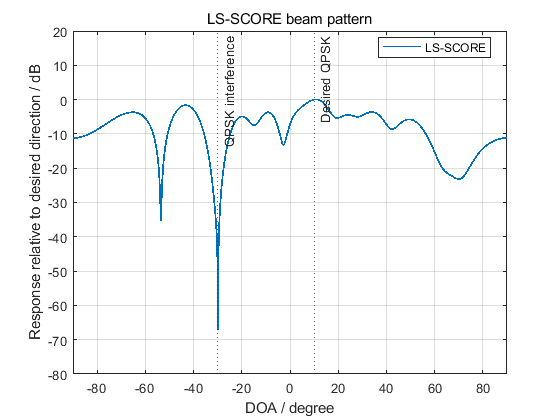

In [52]:

%% 11. Beam pattern
theta_scan = -90:0.1:90;
A_scan = exp(-1j*2*pi/lambda * position * sind(theta_scan));
B = abs(w_opt' * A_scan);

% Plot relative to the desired-direction response.
% This is only an evaluation normalization, so the desired direction is 0 dB.
B_target_ref_dB = 20*log10(B/(abs(w_opt' * a_s) + eps) + 1e-12);

figure;
plot(theta_scan, B_target_ref_dB, 'LineWidth', 1.3);
hold on;
xline(theta_s, ':', 'Desired QPSK');
xline(theta_i, ':', 'QPSK interference');
grid on;
xlim([-90 90]);
ylim([-80 20]);
xlabel('DOA / degree');
ylabel('Response relative to desired direction / dB');
title('LS-SCORE beam pattern');
legend('LS-SCORE','Location','best');

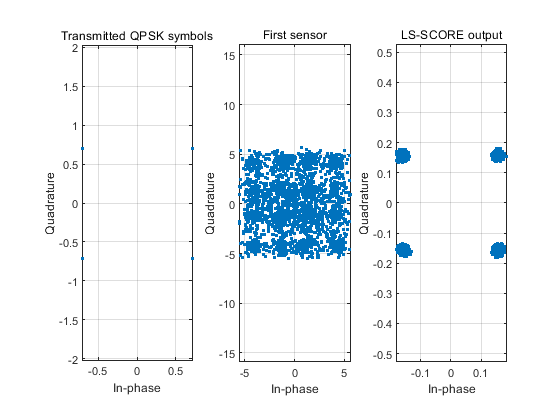

In [53]:
%% 12. Matched filtering and constellation
x1_mf = conv(X(1,:), rrc);
y_mf = conv(y_score, rrc);

sample_index = gd + 1 + (0:Nsym-1)*sps;
x1_sym = x1_mf(sample_index);
y_sym = y_mf(sample_index);

valid = (span+1):(Nsym-span);
s_ref = sym_s(valid);
x1_valid = x1_sym(valid);
y_valid = y_sym(valid);

% % Oracle complex-scalar alignment for plotting only
% gain_x1 = (s_ref*x1_valid')/(x1_valid*x1_valid');
% gain_y = (s_ref*y_valid')/(y_valid*y_valid');
%
% x1_aligned = gain_x1*x1_valid;
% y_aligned = gain_y*y_valid;
%
% evm_x1 = sqrt(mean(abs(x1_aligned-s_ref).^2)/mean(abs(s_ref).^2));
% evm_y  = sqrt(mean(abs(y_aligned-s_ref).^2)/mean(abs(s_ref).^2));

% fprintf('First-sensor EVM        = %.2f %%\n', 100*evm_x1);
% fprintf('LS-SCORE output EVM     = %.2f %%\n', 100*evm_y);

Nplot = 2500;
idx = max(1,length(valid)-Nplot+1):length(valid);

figure;
subplot(1,3,1);
plot(real(s_ref(idx)), imag(s_ref(idx)), '.');
axis equal; grid on;
xlabel('In-phase'); ylabel('Quadrature');
title('Transmitted QPSK symbols');

subplot(1,3,2);
plot(real(x1_valid(idx)), imag(x1_valid(idx)), '.');
axis equal; grid on;
xlabel('In-phase'); ylabel('Quadrature');
title('First sensor');

subplot(1,3,3);
plot(real(y_valid(idx)), imag(y_valid(idx)), '.');
axis equal; grid on;
xlabel('In-phase'); ylabel('Quadrature');
title('LS-SCORE output');

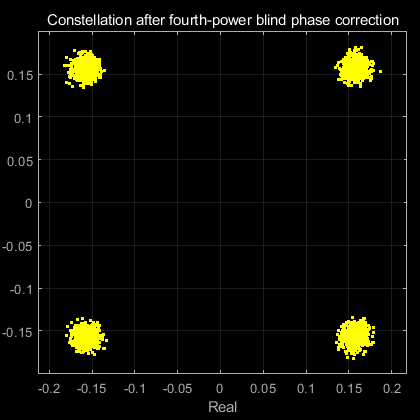

In [54]:

% Applicable to pskmod(...,4,pi/4,...)
phi_hat_blind = unwrap(angle(-mean(y_valid(idx).^4)) / 4);

y_blind_corrected = y_valid(idx) * exp(-1j*phi_hat_blind);

figure;
scatterplot(y_blind_corrected)
grid on;
axis equal;
xlabel('Real');
ylabel('Imag');
title('Constellation after fourth-power blind phase correction');